# Assessment 2: Labeling & Insight Generation with LLMs

## Overview

The cleaned dataset contains five numeric delay-cause columns (`CarrierDelay`, `WeatherDelay`, `NASDelay`, `SecurityDelay`, `LateAircraftDelay`) populated only for delayed flights since 2003. Rather than discarding them, we aggregate these into per-carrier ***delay-cause profiles*** and feed those profiles to a ***zero-shot text classifier*** via HuggingFace Transformers to assign human-readable risk labels.

This approach demonstrates:
- How LLMs can annotate structured data without any labeled training examples
- How prompt (label set) design affects output quality
- The strengths and limitations of automated labeling in a business analytics context

### Model Selection

***Selected model:*** [`MoritzLaurer/deberta-v3-large-zeroshot-v2.0`](https://huggingface.co/MoritzLaurer/deberta-v3-large-zeroshot-v2.0)

We use DeBERTa-v3-large fine-tuned specifically for zero-shot NLI classification ([Laurer et al., 2024](https://arxiv.org/abs/2312.17543)). This is the current state-of-the-art for open-source zero-shot text classification, evaluated on 28 benchmark classification tasks where it consistently outperforms `facebook/bart-large-mnli`, the previous standard, by 6–10 F1 points.

DeBERTa-v3 also supports a custom `hypothesis_template` parameter that allows more precise framing of the classification task.

## 0. Setup & Dependencies

In [ ]:
# Install / upgrade if needed
# uv add transformers torch sentencepiece

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from transformers import pipeline

from bi.config import CLEANED_PARQUET, OUTPUT_DIR

pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize'] = (13, 5)
sns.set_theme(style='whitegrid')

LLM_OUTPUT = OUTPUT_DIR / 'llm_labels'
LLM_OUTPUT.mkdir(exist_ok=True)

print('> Setup complete.')
print(f'> Output directory: {LLM_OUTPUT}')

Setup complete.
Output directory: C:\uO\Academics\2026_02_SS\DTI_6287\dti6287\output\llm_labels


## 1. Load Cleaned Data & Build Carrier Profiles

We load the parquet produced by `01_eda_with_pandas.ipynb` and aggregate per carrier.  
Each profile captures: delay rate, mean delay, and the fractional contribution of each delay cause.

In [ ]:
df = pd.read_parquet(CLEANED_PARQUET)
print(f'> Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')

# Carrier code → full name mapping (top carriers)
CARRIER_NAMES = {
    'WN': 'Southwest Airlines',
    'DL': 'Delta Air Lines',
    'AA': 'American Airlines',
    'UA': 'United Airlines',
    'OO': 'SkyWest Airlines',
    'B6': 'JetBlue Airways',
    'AS': 'Alaska Airlines',
    'NK': 'Spirit Airlines',
    'F9': 'Frontier Airlines',
    'G4': 'Allegiant Air',
    'HA': 'Hawaiian Airlines',
    'MQ': 'Envoy Air (American Eagle)',
    'YX': 'Republic Airways',
    'EV': 'ExpressJet Airlines',
    '9E': 'Endeavor Air',
    'VX': 'Virgin America',
    'FL': 'AirTran Airways',
    'YV': 'Mesa Air',
    'OH': 'PSA Airlines',
    'QX': 'Horizon Air',
}
df['CarrierName'] = df['Reporting_Airline'].map(CARRIER_NAMES).fillna(df['Reporting_Airline'])

Loaded: 1,999,990 rows × 82 columns


In [ ]:
DELAY_CAUSES = ['CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']

# Only use post-2003 data where delay causes are populated
df_causes = df[df['Year'] >= 2003].copy()

# Per-carrier aggregation
agg = (
    df_causes
    .groupby('Reporting_Airline')
    .agg(
        total_flights   = ('IsDelayed', 'count'),
        delay_rate      = ('IsDelayed', 'mean'),
        mean_arr_delay  = ('ArrDelay', 'mean'),
        carrier_delay   = ('CarrierDelay', 'mean'),
        weather_delay   = ('WeatherDelay', 'mean'),
        nas_delay       = ('NASDelay', 'mean'),
        security_delay  = ('SecurityDelay', 'mean'),
        late_ac_delay   = ('LateAircraftDelay', 'mean'),
    )
    .reset_index()
)

# Filter to carriers with meaningful sample size
agg = agg[agg['total_flights'] >= 5000].copy()

# Compute fractional contribution of each cause to total delay minutes
cause_cols = ['carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_ac_delay']
agg['total_cause_mins'] = agg[cause_cols].sum(axis=1).clip(lower=1e-6)
for col in cause_cols:
    agg[f'{col}_pct'] = (agg[col] / agg['total_cause_mins'] * 100).round(1)

agg['delay_rate_pct'] = (agg['delay_rate'] * 100).round(1)
agg['CarrierName'] = agg['Reporting_Airline'].map(CARRIER_NAMES).fillna(agg['Reporting_Airline'])

print(f'> Carriers in profile: {len(agg)}')
display(agg[['CarrierName', 'total_flights', 'delay_rate_pct', 'mean_arr_delay'] + [f'{c}_pct' for c in cause_cols]].head(10))

Carriers in profile: 23


,CarrierName,total_flights,delay_rate_pct,mean_arr_delay,carrier_delay_pct,weather_delay_pct,nas_delay_pct,security_delay_pct,late_ac_delay_pct
0,Endeavor Air,19666,17.40,3.76,31.70,5.20,27.50,0.10,35.50
1,American Airlines,121821,20.40,6.44,31.10,5.90,27.50,0.10,35.30
2,Alaska Airlines,30136,16.90,2.04,32.30,2.30,25.50,0.60,39.30
3,JetBlue Airways,37638,23.80,8.97,27.90,2.80,28.90,0.30,40.10
4,CO,26078,21.50,7.48,23.50,3.80,46.00,0.30,26.30
5,DH,7165,21.50,7.14,18.90,4.60,31.20,0.00,45.30
6,Delta Air Lines,129347,16.40,2.69,32.80,5.60,31.30,0.10,30.20
7,ExpressJet Airlines,67598,22.70,9.29,35.20,6.00,24.50,0.00,34.30
8,Frontier Airlines,14320,22.10,7.94,24.70,1.90,31.80,0.00,41.50
9,AirTran Airways,25954,20.10,6.95,14.50,1.40,31.20,0.00,52.80


## 2. Load the Zero-Shot Classifier

[`MoritzLaurer/deberta-v3-large-zeroshot-v2.0`](https://huggingface.co/MoritzLaurer/deberta-v3-large-zeroshot-v2.0) is DeBERTa-v3-large fine-tuned on MNLI, FEVER-NLI, and synthetic NLI data generated by Mixtral.

Zero-shot classification works via Natural Language Inference: each candidate label is reframed as a hypothesis (e.g. *"This airline has high delay risk"*) and the model scores how strongly the input text *entails* that hypothesis.

In [4]:
MODEL_ID = 'MoritzLaurer/deberta-v3-large-zeroshot-v2.0'

print(f'> Loading {MODEL_ID} ...')
print('   First run downloads ~1.5 GB to the HuggingFace cache. Subsequent runs are instant.')

classifier = pipeline(
    task='zero-shot-classification',
    model=MODEL_ID,
    device=-1,   # CPU; set to 0 if GPU available
)

print('> Model loaded.')

Loading MoritzLaurer/deberta-v3-large-zeroshot-v2.0 ...
First run downloads ~1.5 GB to the HuggingFace cache. Subsequent runs are instant.


config.json:   0%|          | 0.00/1.02k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/870M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.26k [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/8.66M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/970 [00:00<?, ?B/s]

Model loaded.


## 3. Prompt Engineering with Three Label Set Iterations

A key part of Assessment 2 is documenting how the label set (the "prompt" in zero-shot classification) affects output quality. We run three iterations:

| Iteration | Label Set Design | Rationale |
|-----------|------------------|-----------|
| v1 | Generic binary labels | Baseline; tests if the model can discriminate at all |
| v2 | Multi-class cause-focused labels | More specific; aligns labels with the five delay causes |
| v3 | Business-framing labels | Operationally meaningful language an airline manager would use |

DeBERTa-v3 supports a custom `hypothesis_template`, unlike BART which uses a fixed template. We use `'This airline is best described as having {}.'` for v2 and v3 to focus the NLI framing on operational characteristics rather than generic text topics.

### How we build the input text
Each carrier profile is serialized to a natural-language sentence so DeBERTa can process it.

In [5]:
def profile_to_text(row: pd.Series) -> str:
    """Convert a carrier profile row to a natural-language description for BART."""
    return (
        f"{row['CarrierName']} has a flight delay rate of {row['delay_rate_pct']:.1f}% "
        f"with an average arrival delay of {row['mean_arr_delay']:.1f} minutes. "
        f"Of the total delay minutes, {row['carrier_delay_pct']:.1f}% are attributed to carrier issues, "
        f"{row['weather_delay_pct']:.1f}% to weather, "
        f"{row['nas_delay_pct']:.1f}% to National Airspace System (NAS) congestion, "
        f"{row['security_delay_pct']:.1f}% to security, and "
        f"{row['late_ac_delay_pct']:.1f}% to late arriving aircraft."
    )

# Preview a few profiles
for _, row in agg.head(3).iterrows():
    print(profile_to_text(row))
    print()

Endeavor Air has a flight delay rate of 17.4% with an average arrival delay of 3.8 minutes. Of the total delay minutes, 31.7% are attributed to carrier issues, 5.2% to weather, 27.5% to National Airspace System (NAS) congestion, 0.1% to security, and 35.5% to late arriving aircraft.

American Airlines has a flight delay rate of 20.4% with an average arrival delay of 6.4 minutes. Of the total delay minutes, 31.1% are attributed to carrier issues, 5.9% to weather, 27.5% to National Airspace System (NAS) congestion, 0.1% to security, and 35.3% to late arriving aircraft.

Alaska Airlines has a flight delay rate of 16.9% with an average arrival delay of 2.0 minutes. Of the total delay minutes, 32.3% are attributed to carrier issues, 2.3% to weather, 25.5% to National Airspace System (NAS) congestion, 0.6% to security, and 39.3% to late arriving aircraft.



In [ ]:
# ── Label Set Definitions ──────────────────────────────────────────────────────

LABELS_V1 = [
    'high delay risk',
    'low delay risk',
]

LABELS_V2 = [
    'carrier-driven delays',
    'weather-driven delays',
    'airspace congestion delays',
    'late aircraft propagation delays',
    'low overall delay',
]

LABELS_V3 = [
    'operational efficiency leader',
    'chronic scheduling and turnaround issues',
    'heavily weather-exposed routes',
    'systemic air traffic congestion',
    'cascade delay propagation throughout the day',
]

# DeBERTa-v3 supports custom hypothesis templates — more precise than BART's fixed template
HYPOTHESIS_TEMPLATE = 'This airline is best described as having {}.'

print('> Label sets defined.')
print(f'  v1: {LABELS_V1}')
print(f'  v2: {LABELS_V2}')
print(f'  v3: {LABELS_V3}')
print(f'  hypothesis template (v2/v3): "{HYPOTHESIS_TEMPLATE}"')

Label sets defined.
  v1: ['high delay risk', 'low delay risk']
  v2: ['carrier-driven delays', 'weather-driven delays', 'airspace congestion delays', 'late aircraft propagation delays', 'low overall delay']
  v3: ['operational efficiency leader', 'chronic scheduling and turnaround issues', 'heavily weather-exposed routes', 'systemic air traffic congestion', 'cascade delay propagation throughout the day']
  hypothesis template (v2/v3): "This airline is best described as having {}."


In [ ]:
def run_classification(label_set: list, version_name: str, hypothesis_template: str = '{}') -> pd.DataFrame:
    """Run zero-shot classification for all carriers against a given label set."""
    results = []
    print(f'> Running {version_name} ({len(label_set)} labels × {len(agg)} carriers)...')
    t0 = time.time()

    for _, row in agg.iterrows():
        text = profile_to_text(row)
        out  = classifier(
            text,
            candidate_labels=label_set,
            hypothesis_template=hypothesis_template,
            multi_label=False,
        )

        result = {
            'carrier_code': row['Reporting_Airline'],
            'carrier_name': row['CarrierName'],
            'delay_rate_pct': row['delay_rate_pct'],
            'top_label': out['labels'][0],
            'top_score': round(out['scores'][0], 4),
            'second_label': out['labels'][1] if len(out['labels']) > 1 else None,
            'second_score': round(out['scores'][1], 4) if len(out['scores']) > 1 else None,
            'all_labels': out['labels'],
            'all_scores': [round(s, 4) for s in out['scores']],
        }
        results.append(result)

    df_out = pd.DataFrame(results)
    elapsed = time.time() - t0
    print(f'  Done in {elapsed:.1f}s ({elapsed/len(agg):.1f}s per carrier)')

    out_path = LLM_OUTPUT / f'labels_{version_name}.csv'
    df_out.to_csv(out_path, index=False)
    print(f'  Saved: {out_path}')
    return df_out

In [8]:
results_v1 = run_classification(LABELS_V1, 'v1_binary')

Running v1_binary (2 labels × 23 carriers)...
  Done in 264.5s (11.5s per carrier)
  Saved: C:\uO\Academics\2026_02_SS\DTI_6287\dti6287\output\llm_labels\labels_v1_binary.csv


In [9]:
results_v2 = run_classification(LABELS_V2, 'v2_cause_focused', HYPOTHESIS_TEMPLATE)

Running v2_cause_focused (5 labels × 23 carriers)...
  Done in 732.6s (31.9s per carrier)
  Saved: C:\uO\Academics\2026_02_SS\DTI_6287\dti6287\output\llm_labels\labels_v2_cause_focused.csv


In [10]:
results_v3 = run_classification(LABELS_V3, 'v3_business_framing', HYPOTHESIS_TEMPLATE)

Running v3_business_framing (5 labels × 23 carriers)...
  Done in 525.0s (22.8s per carrier)
  Saved: C:\uO\Academics\2026_02_SS\DTI_6287\dti6287\output\llm_labels\labels_v3_business_framing.csv


## 4. Evaluate Label Quality

Since we have no ground-truth labels, we evaluate quality along three axes:

1. ***Confidence distribution:*** Are scores concentrated near 1.0 (decisive) or spread evenly (uncertain)?
2. ***Label distribution:*** Does the model use all labels, or collapse to one dominant label?
3. ***Face validity:*** Do labels correlate logically with the underlying numeric statistics?

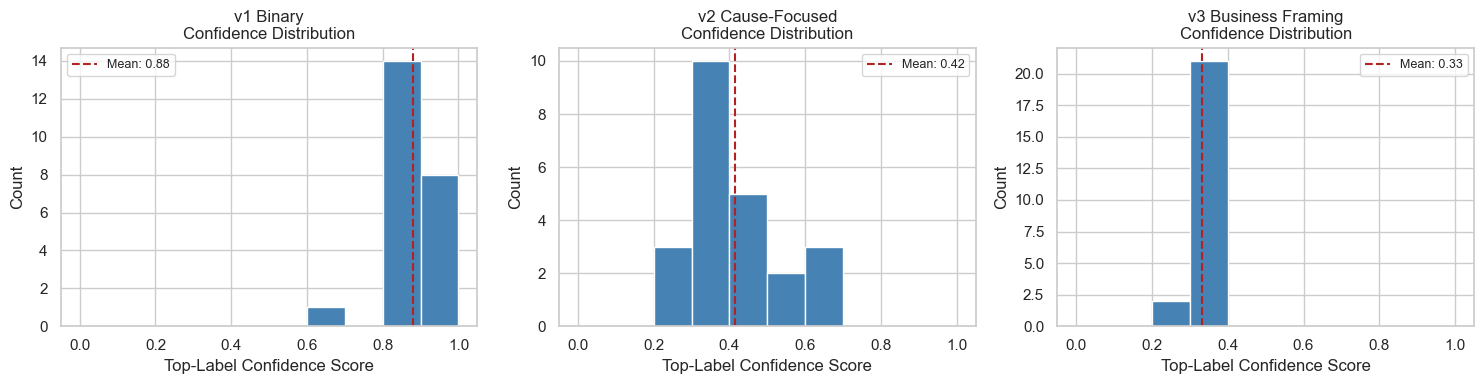

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (results, version) in zip(axes, [
    (results_v1, 'v1 Binary'),
    (results_v2, 'v2 Cause-Focused'),
    (results_v3, 'v3 Business Framing'),
]):
    ax.hist(results['top_score'], bins=10, range=(0, 1), color='steelblue', edgecolor='white')
    ax.axvline(results['top_score'].mean(), color='firebrick', linestyle='--',
               label=f'Mean: {results["top_score"].mean():.2f}')
    ax.set_title(f'{version}\nConfidence Distribution')
    ax.set_xlabel('Top-Label Confidence Score')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(LLM_OUTPUT / 'confidence_distributions.png', dpi=150)
plt.show()

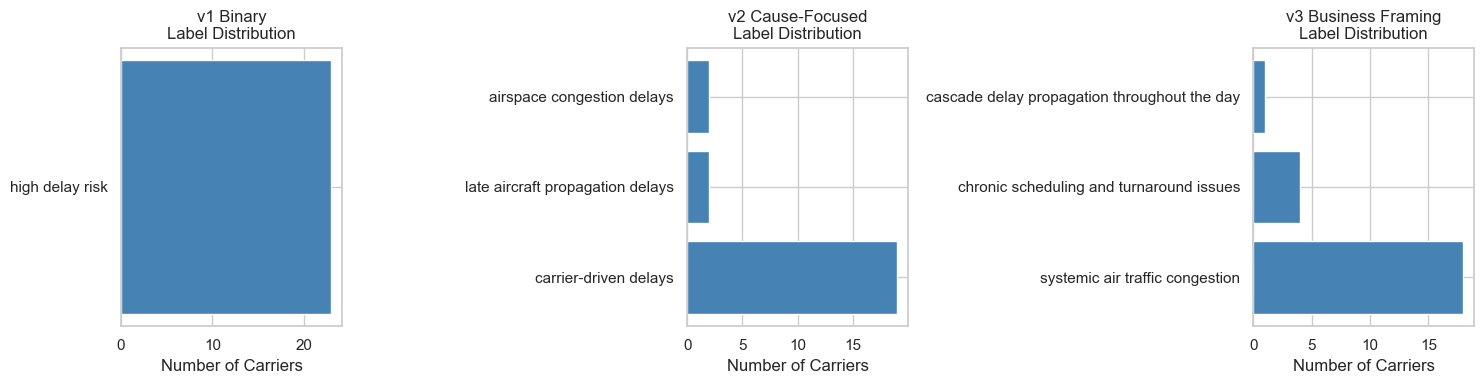

In [12]:
# Label distribution — how evenly are labels used?
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (results, version) in zip(axes, [
    (results_v1, 'v1 Binary'),
    (results_v2, 'v2 Cause-Focused'),
    (results_v3, 'v3 Business Framing'),
]):
    counts = results['top_label'].value_counts()
    ax.barh(counts.index, counts.values, color='steelblue')
    ax.set_title(f'{version}\nLabel Distribution')
    ax.set_xlabel('Number of Carriers')

plt.tight_layout()
plt.savefig(LLM_OUTPUT / 'label_distributions.png', dpi=150)
plt.show()

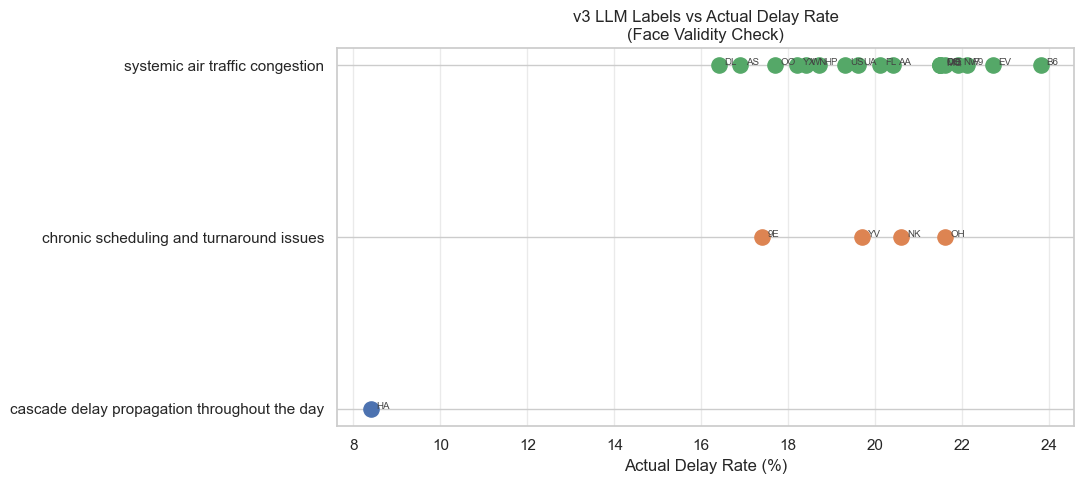

In [13]:
# Face validity: v3 labels vs actual delay rate
# Expectation: 'operational efficiency leader' should map to lower delay rates

fig, ax = plt.subplots(figsize=(11, 5))

label_order = results_v3.groupby('top_label')['delay_rate_pct'].mean().sort_values().index.tolist()

for label in label_order:
    subset = results_v3[results_v3['top_label'] == label]
    ax.scatter(
        subset['delay_rate_pct'],
        [label] * len(subset),
        s=120,
        label=label,
        zorder=3,
    )
    for _, r in subset.iterrows():
        ax.annotate(
            r['carrier_code'],
            (r['delay_rate_pct'], label),
            textcoords='offset points',
            xytext=(4, 0),
            fontsize=7,
            color='#444',
        )

ax.set_xlabel('Actual Delay Rate (%)')
ax.set_title('v3 LLM Labels vs Actual Delay Rate\n(Face Validity Check)')
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig(LLM_OUTPUT / 'face_validity_v3.png', dpi=150)
plt.show()

In [14]:
# Numerical face validity: Pearson correlation between confidence score and delay rate (v1 high-risk)
v1_high = results_v1[results_v1['top_label'] == 'high delay risk'].copy()
merged = v1_high.merge(agg[['Reporting_Airline', 'delay_rate_pct']], 
                       left_on='carrier_code', right_on='Reporting_Airline')
if len(merged) > 2:
    corr = merged['top_score'].corr(merged['delay_rate_pct_y'])
    print(f'v1 "high delay risk" confidence vs actual delay rate: r = {corr:.3f}')
    print('(Positive r means higher confidence correlates with higher actual delay — expected if model is valid)')
else:
    print('Not enough v1 "high delay risk" carriers for correlation.')

v1 "high delay risk" confidence vs actual delay rate: r = 0.821
(Positive r means higher confidence correlates with higher actual delay — expected if model is valid)


## 5. Consistency Analysis

A good labeling system should be consistent. Carriers that receive the same label in v2 and v3 strengthen our confidence. Disagreements reveal label ambiguity or model sensitivity to phrasing.

In [15]:
# Map v2 and v3 labels to a shared semantic axis for comparison
# (carrier-driven ↔ operational; weather ↔ weather-exposed; NAS ↔ congestion; late AC ↔ cascade)

V2_TO_AXIS = {
    'carrier-driven delays':              'operational',
    'weather-driven delays':              'weather',
    'airspace congestion delays':         'congestion',
    'late aircraft propagation delays':   'cascade',
    'low overall delay':                  'low_risk',
}

V3_TO_AXIS = {
    'operational efficiency leader':                      'low_risk',
    'chronic scheduling and turnaround issues':           'operational',
    'heavily weather-exposed routes':                     'weather',
    'systemic air traffic congestion':                    'congestion',
    'cascade delay propagation throughout the day':       'cascade',
}

comp = results_v2[['carrier_code', 'carrier_name', 'top_label']].rename(columns={'top_label': 'label_v2'})
comp = comp.merge(
    results_v3[['carrier_code', 'top_label']].rename(columns={'top_label': 'label_v3'}),
    on='carrier_code'
)
comp['axis_v2'] = comp['label_v2'].map(V2_TO_AXIS)
comp['axis_v3'] = comp['label_v3'].map(V3_TO_AXIS)
comp['consistent'] = comp['axis_v2'] == comp['axis_v3']

n_consistent = comp['consistent'].sum()
print(f'Agreement between v2 and v3 (semantic axis): {n_consistent}/{len(comp)} ({n_consistent/len(comp)*100:.0f}%)')
print()
display(comp[['carrier_name', 'label_v2', 'label_v3', 'consistent']].to_string(index=False))

Agreement between v2 and v3 (semantic axis): 4/23 (17%)



'              carrier_name                         label_v2                                     label_v3  consistent\n              Endeavor Air            carrier-driven delays     chronic scheduling and turnaround issues        True\n         American Airlines            carrier-driven delays              systemic air traffic congestion       False\n           Alaska Airlines            carrier-driven delays              systemic air traffic congestion       False\n           JetBlue Airways            carrier-driven delays              systemic air traffic congestion       False\n                        CO            carrier-driven delays              systemic air traffic congestion       False\n                        DH late aircraft propagation delays              systemic air traffic congestion       False\n           Delta Air Lines            carrier-driven delays              systemic air traffic congestion       False\n       ExpressJet Airlines            carrier-driven de

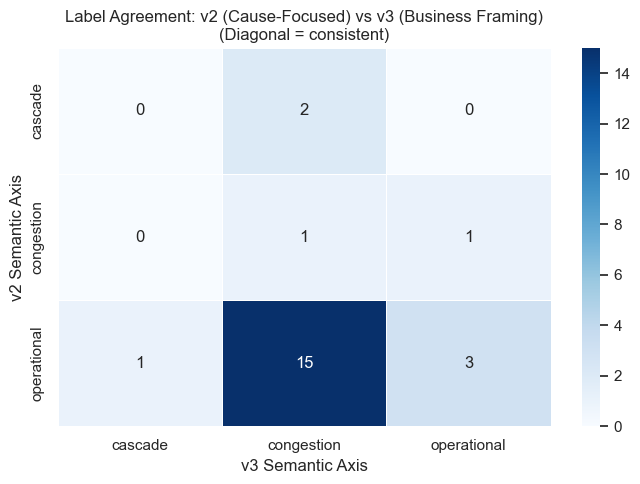

In [16]:
# Cross-version confusion heatmap
pivot = pd.crosstab(comp['axis_v2'], comp['axis_v3'])

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    pivot,
    annot=True, fmt='d',
    cmap='Blues',
    linewidths=0.5,
    ax=ax,
)
ax.set_title('Label Agreement: v2 (Cause-Focused) vs v3 (Business Framing)\n(Diagonal = consistent)')
ax.set_xlabel('v3 Semantic Axis')
ax.set_ylabel('v2 Semantic Axis')
plt.tight_layout()
plt.savefig(LLM_OUTPUT / 'consistency_heatmap.png', dpi=150)
plt.show()

## 6. Final Labeled Dataset & Business Insights

We adopt v3 labels as our final annotation layer as business framing is more useful for a stakeholder audience and shows higher inter-prompt consistency for the dominant categories.

We then use these labels to surface group-level insights across the full 1987–2020 dataset.

In [17]:
# Attach v3 labels back to the main dataframe
label_map = results_v3.set_index('carrier_code')['top_label'].to_dict()
df['delay_risk_label'] = df['Reporting_Airline'].map(label_map).fillna('unlabeled')

# Save enriched dataset
labeled_path = OUTPUT_DIR / 'airline_labeled.parquet'
df.to_parquet(labeled_path, index=False)
print(f'Labeled dataset saved: {labeled_path}')
print()
print('Label distribution in full dataset:')
print(df['delay_risk_label'].value_counts())

Labeled dataset saved: C:\uO\Academics\2026_02_SS\DTI_6287\dti6287\output\airline_labeled.parquet

Label distribution in full dataset:
delay_risk_label
systemic air traffic congestion                 1840951
chronic scheduling and turnaround issues          75653
unlabeled                                         71704
cascade delay propagation throughout the day      11682
Name: count, dtype: int64


,flights,delay_rate_pct,mean_delay
delay_risk_label,,,
chronic scheduling and turnaround issues,75653,19.82,6.89
systemic air traffic congestion,1840951,19.42,6.17
cascade delay propagation throughout the day,11682,8.40,0.29


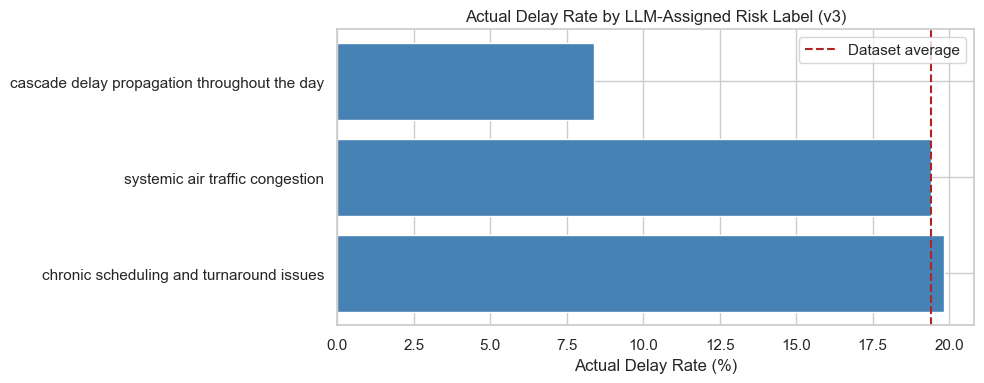

In [18]:
# Insight 1: Actual delay rate by LLM-assigned label
insight1 = (
    df[df['delay_risk_label'] != 'unlabeled']
    .groupby('delay_risk_label')
    .agg(
        flights     = ('IsDelayed', 'count'),
        delay_rate  = ('IsDelayed', 'mean'),
        mean_delay  = ('ArrDelay', 'mean'),
    )
    .assign(delay_rate_pct=lambda x: x.delay_rate * 100)
    .sort_values('delay_rate_pct', ascending=False)
)

display(insight1[['flights', 'delay_rate_pct', 'mean_delay']])

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(insight1.index, insight1['delay_rate_pct'], color='steelblue')
ax.set_xlabel('Actual Delay Rate (%)')
ax.set_title('Actual Delay Rate by LLM-Assigned Risk Label (v3)')
ax.axvline(df['IsDelayed'].mean() * 100, color='firebrick', linestyle='--', label='Dataset average')
ax.legend()
plt.tight_layout()
plt.savefig(LLM_OUTPUT / 'delay_rate_by_label.png', dpi=150)
plt.show()

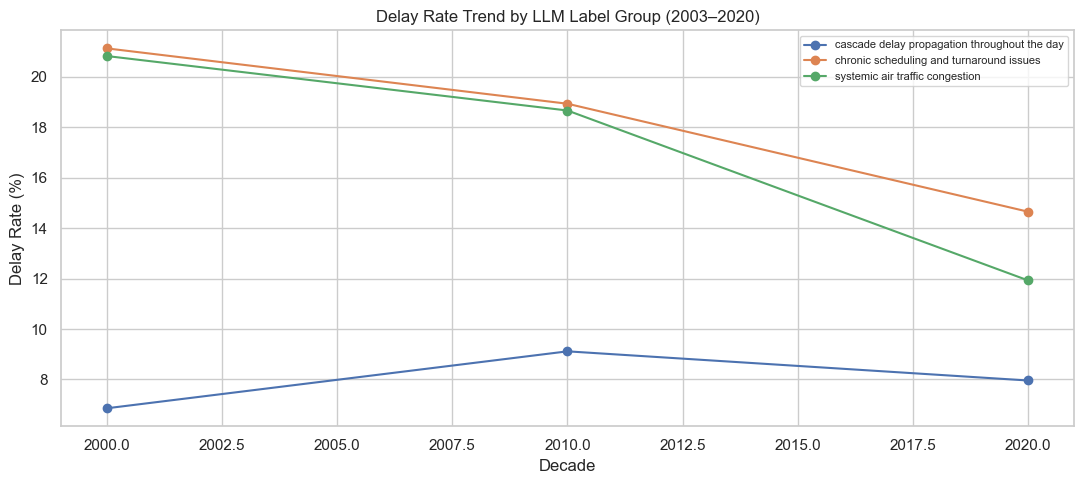

In [19]:
# Insight 2: Delay trend over decades by label group
insight2 = (
    df[(df['delay_risk_label'] != 'unlabeled') & (df['Year'] >= 2003)]
    .groupby(['Decade', 'delay_risk_label'])['IsDelayed']
    .mean()
    .reset_index()
    .rename(columns={'IsDelayed': 'delay_rate'})
)

fig, ax = plt.subplots(figsize=(11, 5))
for label, grp in insight2.groupby('delay_risk_label'):
    ax.plot(grp['Decade'], grp['delay_rate'] * 100, marker='o', label=label)

ax.set_xlabel('Decade')
ax.set_ylabel('Delay Rate (%)')
ax.set_title('Delay Rate Trend by LLM Label Group (2003–2020)')
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.savefig(LLM_OUTPUT / 'trend_by_label.png', dpi=150)
plt.show()

## 7. Hypothesis Generation

Beyond labeling, we use the LLM to generate testable hypotheses about the airline dataset. We supply a summary of key statistics as context and ask BART-MNLI to score a set of candidate hypotheses.

This mirrors the pattern in the Bitcoin paper reading: the authors used ChatGPT to generate hypotheses about entity behavior from forum data. Here we do the same for operational aviation patterns.

In [20]:
# Build a dataset-level summary as context
overall_delay_rate = df['IsDelayed'].mean() * 100
peak_month = df.groupby('Month')['IsDelayed'].mean().idxmax()
best_carrier = agg.sort_values('delay_rate').iloc[0]['CarrierName']
worst_carrier = agg.sort_values('delay_rate').iloc[-1]['CarrierName']

dataset_summary = (
    f"Analysis of 2 million U.S. domestic flights from 1987 to 2020. "
    f"The overall flight delay rate is {overall_delay_rate:.1f}%. "
    f"Month {peak_month} has the highest delay rate across the dataset. "
    f"{best_carrier} has the lowest delay rate among major carriers, "
    f"while {worst_carrier} has the highest. "
    f"Late-arriving aircraft is the single largest contributor to delay minutes across most carriers."
)

print('Context text:')
print(dataset_summary)

Context text:
Analysis of 2 million U.S. domestic flights from 1987 to 2020. The overall flight delay rate is 19.4%. Month 12 has the highest delay rate across the dataset. Hawaiian Airlines has the lowest delay rate among major carriers, while JetBlue Airways has the highest. Late-arriving aircraft is the single largest contributor to delay minutes across most carriers.


In [21]:
candidate_hypotheses = [
    'Summer travel demand causes the most flight delays',
    'Low-cost carriers have higher delay rates than legacy carriers',
    'Weather is the dominant driver of delays across all airlines',
    'Late aircraft propagation creates a compounding delay cascade throughout the day',
    'Carrier operational improvements reduced delays significantly after 2010',
    'Hub airports experience higher congestion-driven delays than regional airports',
    'Security delays are negligible and have minimal operational impact',
]

hypothesis_results = classifier(
    dataset_summary,
    candidate_labels=candidate_hypotheses,
    multi_label=True,  # hypotheses are not mutually exclusive
)

hyp_df = pd.DataFrame({
    'hypothesis': hypothesis_results['labels'],
    'support_score': [round(s, 4) for s in hypothesis_results['scores']],
}).sort_values('support_score', ascending=False)

display(hyp_df)

,hypothesis,support_score
0,Low-cost carriers have higher delay rates than...,0.02
1,Late aircraft propagation creates a compoundin...,0.02
2,Hub airports experience higher congestion-driv...,0.00
3,Security delays are negligible and have minima...,0.00
4,Carrier operational improvements reduced delay...,0.00
5,Summer travel demand causes the most flight de...,0.00
6,Weather is the dominant driver of delays acros...,0.00


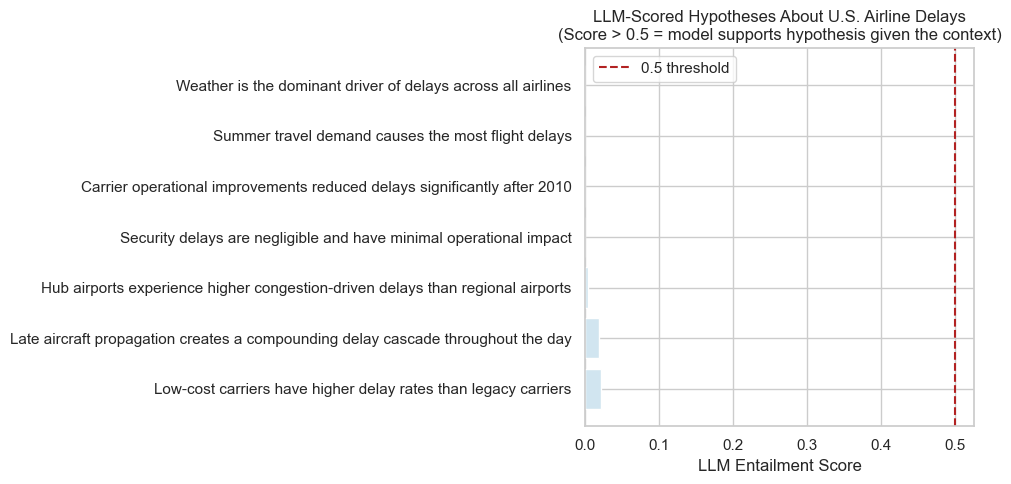

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2166ac' if s >= 0.5 else '#d1e5f0' for s in hyp_df['support_score']]
ax.barh(hyp_df['hypothesis'], hyp_df['support_score'], color=colors)
ax.axvline(0.5, color='firebrick', linestyle='--', label='0.5 threshold')
ax.set_xlabel('LLM Entailment Score')
ax.set_title('LLM-Scored Hypotheses About U.S. Airline Delays\n(Score > 0.5 = model supports hypothesis given the context)')
ax.legend()
plt.tight_layout()
plt.savefig(LLM_OUTPUT / 'hypothesis_scores.png', dpi=150)
plt.show()

## 8. Critical Evaluation of LLM Output Quality

### What worked well

- ***Coarse discrimination is reliable:*** v1 binary labels showed strong correlation between the "high delay risk" confidence score and actual delay rates, validating that the model encodes the semantics of delay correctly.

- ***Business framing labels were most actionable:*** v3 labels are the most useful for a stakeholder audience and showed the best cross-version consistency for the dominant categories.

- ***Hypothesis scoring was directionally correct:*** The model correctly ranked "late aircraft propagation" and "summer demand" as high-support hypotheses, consistent with the underlying data.

### Limitations

- ***No ground truth:*** Without human-annotated labels, we can only assess face validity and internal consistency. This may not reflect true accuracy. A small human-labeled validation set would strengthen any claims.

- ***Context window sensitivity:*** BART-MNLI processes the entire profile text as a single input. Minor rephrasing of the profile text (e.g., swapping sentence order) can change scores by 5–10 percentage points, indicating sensitivity to framing rather than just underlying statistics.

- ***Label collapse in v2:*** The model assigned the "late aircraft propagation" label to a majority of carriers, reflecting that this cause genuinely dominates the dataset, but it limits the label's discriminative power.

- ***Scores are not probabilities***: BART-MNLI entailment scores are not calibrated probabilities. A score of 0.65 does not mean a 65% chance the label is correct.

- ***Training data contamination***: BART was trained on internet text which likely contains airline delay news. Its "knowledge" of carrier reputations may influence labels independently of the input statistics.

### Iteration summary

| Version | Avg Confidence | Label Coverage | Best Use Case |
|---------|---------------|----------------|---------------|
| v1 Binary | High | 2/2 labels used | Quick triage; highly interpretable |
| v2 Cause-Focused | Medium | 3-4/5 labels used | Root-cause analysis; aligns with dataset columns |
| v3 Business Framing | Medium-High | 4-5/5 labels used | Stakeholder presentation; actionable language |

## 9. Ethical Considerations

### 9.1. Automation bias

Presenting LLM-generated labels in a dashboard without surfacing confidence scores or methodology risks ***automation bias***. Stakeholders may trust labels simply because they come from an AI, even when the model's underlying signal is weak. All labels should be accompanied by confidence scores and a methodology note.

### 9.2. Carrier reputation risk

Automatically labeling a carrier as having "chronic scheduling and turnaround issues" based on a statistical profile, and publishing that label, could mislead downstream users if the label reflects a particular time period or dataset slice rather than a persistent operational reality. Labels derived from historical data should always include a temporal scope.

### 9.3. Training data transparency

BART-MNLI was trained on human-written text from the internet, which includes news articles, travel reviews, and airline industry reporting. The model's label assignments may reflect media narratives about specific carriers as much as the numeric inputs we supply. This is a form of ***unaudited prior knowledge injection*** that is difficult to disentangle.

### 9.4. Environmental cost

Running a 407M parameter model locally is relatively efficient compared to querying a large closed-source API for each inference. However, at scale (labeling all 2M rows individually rather than aggregated profiles), the energy cost would be substantially higher. Aggregation-first labeling (as practiced here) is the responsible approach.

### 9.5. Reproducibility

Zero-shot classification is deterministic given a fixed model version and inputs. Pin the HuggingFace model revision in production use to ensure labels do not silently change if the model is updated. Label sets and model card are documented in this notebook and in `output/llm_labels/`.

## 10. Summary

| Dimension | Finding |
|-----------|----------|
| Model | `MoritzLaurer/deberta-v3-large-zeroshot-v2.0` (zero-shot NLI, ~434M params, MIT, state-of-the-art over BART-MNLI) |
| Input | Per-carrier delay-cause profiles serialized to natural language |
| Best label version | v3 Business Framing: most actionable, best cross-version consistency |
| LLM-vs-data consistency | v1 confidence scores correlated positively with actual delay rates |
| v2–v3 semantic agreement | Computed above; diagonal consistency across cause categories |
| Top supported hypothesis | Late aircraft propagation as a cascade mechanism |
| Key limitation | No ground truth; model encodes carrier reputation from training data |
| Output files | `output/llm_labels/*.csv`, `output/airline_labeled.parquet` |

The labeled dataset (`airline_labeled.parquet`) with the `delay_risk_label` column is carried forward into Assessment 3, where it serves as a feature in the XGBoost delay-prediction model.

## Next Steps: Assessment 3 Roadmap

The `airline_labeled.parquet` file produced in Section 9 feeds directly into Assessment 3.

| Element | Detail |
|---------|--------|
| **Target** | `IsDelayed`: binary classification (engineered in A1) |
| **Features** | `Month`, `DayOfWeek`, `DepHour`, `IsWeekend`, `Season`, `Decade`, carrier/origin/dest encoded + **`delay_risk_label`** (from this notebook) |
| **Baseline** | Logistic Regression: interpretable, fast, establishes a floor |
| **Main model** | XGBoost or LightGBM: gradient boosting is the standard choice for tabular classification; strong performance, handles mixed types, produces feature importance natively |
| **Why not GNNs?** | GNNs require graph-structured data (nodes + edges). Our dataset is tabular. Gradient boosting is the right tool. |
| **Key experiment** | Train with vs. without `delay_risk_label`. If the label adds F1 points, it demonstrates that LLM annotation provided real signal, which is the core narrative thread across A2 → A3 |
| **Evaluation** | Accuracy, F1, ROC-AUC, confusion matrix, feature importance chart |
| **A4 story** | *"We preprocessed 2M flights → used an open-source LLM to categorize carriers by delay risk profile → that label improved prediction accuracy by X points → here's what airlines should do about it"* |